<a href="https://colab.research.google.com/github/pratham-magar-13/PyTorch-Tutorial/blob/main/PyTorch_neural_network_classificaiton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Neural network classification using PyTorch**
classification is a problem of predicting whether something is one thing or another (There can be multiple things as the options)

# Make classificaiton data and get it ready

In [5]:
import sklearn
from sklearn.datasets  import make_circles

In [6]:
# make 1000 samples
n_samples=1000

# create circles
X, y=make_circles(n_samples,noise=0.03,random_state=42)

In [7]:
len(X),len(y)

(1000, 1000)

In [8]:
print(f"First 5 samples of X: {X[:5]}")
print(f"First 5 samples of y: {y[:5]}")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

First 5 samples of X: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y: [1 1 1 1 0]
Shape of X: (1000, 2)
Shape of y: (1000,)


In [9]:
# Make DataFrame of circle data
import pandas as pd
circles=pd.DataFrame({"X1":X[:,0],
                     "X2":X[:,1],
                     "label":y})
circles

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


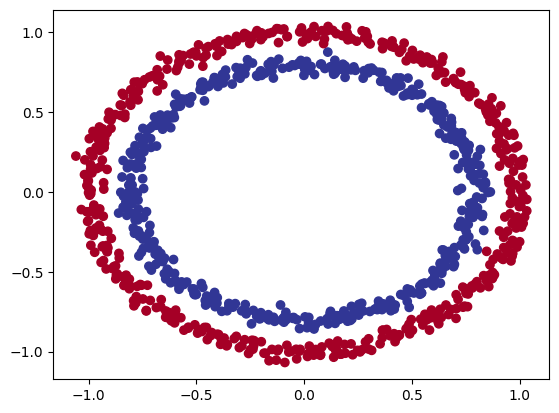

In [10]:
# visualize
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdYlBu)

In [11]:
# view the first example of features and labels
X_sample=X[0]
y_sample=y[0]

print(f"Values for one sample of X: {X_sample} and the same for y:{y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y:1
Shapes for one sample of X: (2,) and the same for y: ()


# Turn data into tensors and create train and test splits


In [12]:
# Turn data into tensors
import torch
torch.__version__

X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)
X[:5]

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])

In [13]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

# Building a model
Lets build a model to classify our blue and red dots.
 To do so , we want to:
 1. Setup device agonistic code so our code wil run on an accelerator(GPU) if there isone
 2. Construct a model(by subclassing `nn.Module`)
 3. Define a loss function and optimizer
 4. Create a training and test loop

In [15]:
from torch import nn
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

Now we have setup device agnostic code, let's create a model that:

1. Subclasses `nn.Module` (almost all models in PyTorch subclass 'nn.Module')
2. Create `nn.Linear()` layers that are capable of handling the shapes of our data
3. Defines a `forward()` method that outlines the forward pass (or forward computation of the model)
4. Instanatiate an instance of our model class and send it to the target `device`

# **1. Construct a model that subclasses nn.Module**

In [16]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    #2. Create two nn.Linear layers capable of handling the shape
    self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features and upscales to 5 features
    self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features frm previous layer and outputs a single feature same as y

    #3. Define a forward method that outlines the forward pass
  def forward(self, x):
    return self.layer_2(self.layer_1(x)) # x-> layer1 -> layer 2
# 4. Instantiate an instance of our model class and send it to the target device
model_0=CircleModelV1().to(device)
model_0

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [17]:
device

'cpu'

In [18]:
next(model_0.parameters()).device

device(type='cpu')

# **Let's replicate the model above using nn.Sequential()**

In [19]:
model_1=nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
)
model_1

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [20]:
model_1.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.4708,  0.3186],
                      [-0.2985,  0.1486],
                      [-0.0844, -0.0278],
                      [ 0.5930, -0.1046],
                      [ 0.1648,  0.2085]])),
             ('0.bias', tensor([-0.3496,  0.3671,  0.5693, -0.3223,  0.3260])),
             ('1.weight',
              tensor([[ 0.4348,  0.1878,  0.2778,  0.2982, -0.0822]])),
             ('1.bias', tensor([0.3875]))])

In [21]:
# **Make predictions**

In [22]:
with torch.inference_mode():
  untrained_preds=model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}")
print(f"Shape of predictions: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}")
print(f"Shape of test samples: {X_test.shape}")
print(f"First 10 predictions: {torch.round(untrained_preds[:10])}")
print(f"First 10 labels: {y_test[:10]}")

Length of predictions: 200
Shape of predictions: torch.Size([200, 1])
Length of test samples: 200
Shape of test samples: torch.Size([200, 2])
First 10 predictions: tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-1.],
        [-1.],
        [-0.],
        [-0.]])
First 10 labels: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


# **Setup loss function and optimizer**

Which loss function or optimizer should you use?

Again.. this is problem specific.

For example for regression you want MAE Or MSE.

For classification try binary cross entropy / log loss or categorical cross entropy.

For optimizers, two of the most common and useful are SGD and Adam, however PyTorch has many built-in options.

#**Setup the loss Function**

In [23]:
loss_fn=nn.BCEWithLogitsLoss() #sigmoid activation function built-in

#**Setup the optimizer**

In [24]:
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)

#**Calculate accuracy**

In [25]:
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=correct/len(y_pred)*100
  return acc

#**Train model**
1. Forward pass
2. Calculate loss
3. Optimizer zero grad
4. Loss backward
5. Optimizer step

#**Going from raw logits -> prediction probabilities -> Prediction labels**

Our model outputs are going to be raw **logits**

We can conver these **logits** into prediction probabilitites by passing them to some kind of activation function (eg: sigmoid for binary cross entropy or log loss and softmax for multiclass)

then we can convert our model's prediction probabilities to ** prediction labels** by either rounding them or taking the `argmax()`

##**View the first 5 outputs of the forward pass on the test data**

In [26]:
model_0.eval()
with torch.inference_mode():
  y_logits=model_0(X_test.to(device))
y_logits[:5]

tensor([[-0.3614],
        [-0.4339],
        [-0.2588],
        [-0.3901],
        [-0.3977]])

#**use the sigmoid functino on our model logits**

In [27]:
y_pred_probs=torch.sigmoid(y_logits)
y_pred_probs[:5]

tensor([[0.4106],
        [0.3932],
        [0.4357],
        [0.4037],
        [0.4019]])

In [28]:
torch.round(y_pred_probs[:5])

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]])

In [29]:
# find the predicted labesl
y_preds=torch.round(y_pred_probs)

#In full
y_pred_labels=torch.round(torch.sigmoid(model_0(X_test.to(device))))
y_pred_labels[:5]

#check for equality
print(torch.eq(y_preds,y_pred_labels))

y_preds.squeeze()


tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.])

# **Building a training and testing loop**

In [30]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#set the number of epochs
epochs=100

#Put data to target device
X_train,y_train=X_train.to(device),y_train.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)

#Build training and evaluation loop
for epoch in range(epochs):
  ##Training
  model_0.train()

  #1. Forward pass
  y_logits=model_0(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits)) # turn logits -> prediction probabilities->pred labels

  #2. Calculate loss/accuracy
  loss=loss_fn(y_logits,y_train)

  acc=accuracy_fn(y_true=y_train, y_pred=y_pred)

  #3. Optimizer zero grad
  optimizer.zero_grad()

  #4. Loss backward
  loss.backward()

  #5. Optimizer step
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    #1. Forward pass
    test_logits=model_0(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    #2. Calculate loss/accuracy
    test_loss=loss_fn(test_logits,y_test)
    test_acc=accuracy_fn(y_true=y_test,y_pred=test_pred)

    # Print out what's happening
    if epoch%10 ==0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")
#

Epoch: 0 | Loss: 0.71274 | Accuracy: 50.00% | Test Loss: 0.70781 | Test Accuracy: 50.00%
Epoch: 10 | Loss: 0.69967 | Accuracy: 50.00% | Test Loss: 0.69627 | Test Accuracy: 50.00%
Epoch: 20 | Loss: 0.69587 | Accuracy: 41.25% | Test Loss: 0.69304 | Test Accuracy: 43.50%
Epoch: 30 | Loss: 0.69466 | Accuracy: 46.75% | Test Loss: 0.69219 | Test Accuracy: 50.50%
Epoch: 40 | Loss: 0.69420 | Accuracy: 47.88% | Test Loss: 0.69202 | Test Accuracy: 53.00%
Epoch: 50 | Loss: 0.69397 | Accuracy: 48.12% | Test Loss: 0.69206 | Test Accuracy: 52.50%
Epoch: 60 | Loss: 0.69381 | Accuracy: 48.38% | Test Loss: 0.69216 | Test Accuracy: 52.50%
Epoch: 70 | Loss: 0.69369 | Accuracy: 48.75% | Test Loss: 0.69228 | Test Accuracy: 52.00%
Epoch: 80 | Loss: 0.69359 | Accuracy: 49.00% | Test Loss: 0.69241 | Test Accuracy: 51.00%
Epoch: 90 | Loss: 0.69350 | Accuracy: 49.00% | Test Loss: 0.69253 | Test Accuracy: 51.50%


#**Make predictions and evaluate the model**
From the metrics it looks like the model isnot learning because we are using linear layer but clearly the data are non linear


#**Improving a model(from a model perspective)**
* Add more layers - give the model more chances to learn about patterns in the data
* Add more hidden units - go from 5 hidden units to 10 hidden units
* Fit for longer
* Changing the activation functions
* Changing the learning rate
* Change the loss function

These options are all from a model's perspective because they deal directly with the model, rather than the data.


#**New model**

* By adding more hidden units: 5 to 10
* Increase the number of layers: 2 to 3
* Increase the number of epoch : 100 to 1000

In [31]:
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    #2. Create two nn.Linear layers capable of handling the shape
    self.layer_1 = nn.Linear(in_features=2, out_features=10) # takes in 2 features and upscales to 10 features
    self.layer_2 = nn.Linear(in_features=10, out_features=10) # takes in 10 features frm previous layer and 10 out features
    self.layer_3 = nn.Linear(in_features=10,out_features=1)

    #3. Define a forward method that outlines the forward pass
  def forward(self, x):
    return self.layer_3(self.layer_2(self.layer_1(x))) # x-> layer1 -> layer 2 ->layer 3
# 4. Instantiate an instance of our model class and send it to the target device
model_2=CircleModelV2().to(device)
model_2

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [32]:
# Create a loss function
loss_fn=nn.BCEWithLogitsLoss()
# Create an optimizer
optimizer=torch.optim.SGD(params=model_2.parameters(),lr=0.1)

In [35]:
# Write a training and evaluation loop for model 2
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#set the number of epochs
epochs=1000

# Put data on the target device
X_train, y_train=X_train.to(device),y_train.to(device)
X_test, y_test=X_test.to(device),y_test.to(device)

for epoch in range(epochs):

  ##Training
  model_2.train()

  #1. Forward pass
  y_logits=model_2(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits)) # logits->pred probabilities->pred labels

  #2 calculate the loss and accuracy
  loss=loss_fn(y_logits,y_train)
  acc=accuracy_fn(y_true=y_train,y_pred=y_pred)

  #3. Optimizer zero grad
  optimizer.zero_grad()

  #4. Loss backward
  loss.backward()

  #5. Optimizer step
  optimizer.step()


  ### Testing
  model_2.eval()
  with torch.inference_mode():
    #1. Forward pass
    test_logits=model_2(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    #2 Calculate loss
    test_loss=loss_fn(test_logits,y_test)
    test_acc=accuracy_fn(y_true=y_test,y_pred=test_pred)

    #3 Print out
    if epoch%100==0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 100 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 200 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 300 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 400 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 500 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 600 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 700 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 800 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%
Epoch: 900 | Loss: 0.69298 | Accuracy: 51.00% | Test Loss: 0.69468 | Test Accuracy: 46.00%


#**Still the accuracy is low and the model isnot learning properly**

#**Building a model with non-linear activation functions**

In [36]:
class CircleModelV3(nn.Module):
  def __init__(self):
    super().__init__()
    #2. Create two nn.Linear layers capable of handling the shape
    self.layer_1 = nn.Linear(in_features=2, out_features=10) # takes in 2 features and upscales to 10 features
    self.layer_2 = nn.Linear(in_features=10, out_features=10) # takes in 10 features frm previous layer and 10 out features
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu=nn.ReLU() # <- add in ReLU activation function ie non linear

    #3. Define a forward method that outlines the forward pass
  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
# 4. Instantiate an instance of our model class and send it to the target device
model_3=CircleModelV3().to(device)
model_3

CircleModelV3(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [38]:
## Setup loss and optimizer
loss_fn=nn.BCEWithLogitsLoss()
# Create an optimizer
optimizer=torch.optim.SGD(params=model_3.parameters(),lr=0.1)

In [39]:
# Write a training and evaluation loop for model 2
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#set the number of epochs
epochs=1000

# Put data on the target device
X_train, y_train=X_train.to(device),y_train.to(device)
X_test, y_test=X_test.to(device),y_test.to(device)

for epoch in range(epochs):

  ##Training
  model_3.train()

  #1. Forward pass
  y_logits=model_3(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits)) # logits->pred probabilities->pred labels

  #2 calculate the loss and accuracy
  loss=loss_fn(y_logits,y_train)
  acc=accuracy_fn(y_true=y_train,y_pred=y_pred)

  #3. Optimizer zero grad
  optimizer.zero_grad()

  #4. Loss backward
  loss.backward()

  #5. Optimizer step
  optimizer.step()


  ### Testing
  model_3.eval()
  with torch.inference_mode():
    #1. Forward pass
    test_logits=model_3(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))

    #2 Calculate loss
    test_loss=loss_fn(test_logits,y_test)
    test_acc=accuracy_fn(y_true=y_test,y_pred=test_pred)

    #3 Print out
    if epoch%100==0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69295 | Accuracy: 50.00% | Test Loss: 0.69319 | Test Accuracy: 50.00%
Epoch: 100 | Loss: 0.69115 | Accuracy: 52.88% | Test Loss: 0.69102 | Test Accuracy: 52.50%
Epoch: 200 | Loss: 0.68977 | Accuracy: 53.37% | Test Loss: 0.68940 | Test Accuracy: 55.00%
Epoch: 300 | Loss: 0.68795 | Accuracy: 53.00% | Test Loss: 0.68723 | Test Accuracy: 56.00%
Epoch: 400 | Loss: 0.68517 | Accuracy: 52.75% | Test Loss: 0.68411 | Test Accuracy: 56.50%
Epoch: 500 | Loss: 0.68102 | Accuracy: 52.75% | Test Loss: 0.67941 | Test Accuracy: 56.50%
Epoch: 600 | Loss: 0.67515 | Accuracy: 54.50% | Test Loss: 0.67285 | Test Accuracy: 56.00%
Epoch: 700 | Loss: 0.66659 | Accuracy: 58.38% | Test Loss: 0.66322 | Test Accuracy: 59.00%
Epoch: 800 | Loss: 0.65160 | Accuracy: 64.00% | Test Loss: 0.64757 | Test Accuracy: 67.50%
Epoch: 900 | Loss: 0.62362 | Accuracy: 74.00% | Test Loss: 0.62145 | Test Accuracy: 79.00%


## Plotting the Decision Boundary

In [41]:
import numpy as np

def plot_decision_boundary(model, X, y):
    # Put everything to CPU (or the device the model is on)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction-making
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Make features for prediction
    X_to_predict_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_predict_on)

    # Convert logits to prediction probabilities
    y_pred_probs = torch.sigmoid(y_logits)

    # Convert prediction probabilities to labels
    y_pred_labels = torch.round(y_pred_probs).squeeze()

    # Reshape predictions:
    y_pred_labels = y_pred_labels.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, y_pred_labels, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.title("Decision Boundary")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.show()

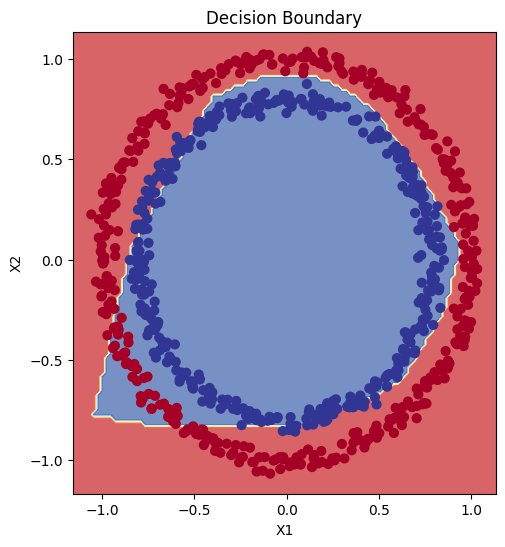

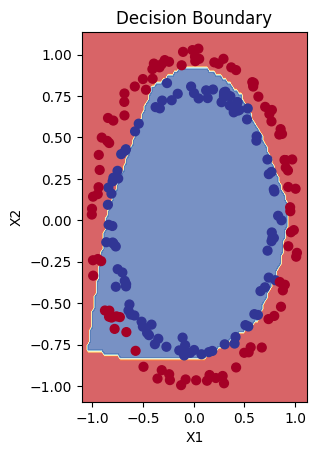

In [42]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)